In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Load the main data and convert index to datetime
data = pd.read_csv("data/Lindon/Lindon_cleaned.csv", index_col=0)
data.index = pd.to_datetime(data.index, errors='coerce')

j_data = pd.read_csv("data/LR_test/JNO2_hourly_avg.csv")
sensor_area = 2.84
j_data["J_NO2"] = j_data['J_NO2']/2.84


# Calculating K 


In [21]:
data['Temp[K]'] = (data['Temp']-32) * 5/9 +273.15

A = 3.0e-12
EoR = 1500
data['K'] = A * np.exp(-EoR/ (data['Temp[K]']))

f298 = 1.07
g = 130
data['f_T'] = f298 * np.exp(g * (1/data['Temp[K]'] - 1/298.0))

# Change concentration Units

In [22]:
# Ideal gas number density (molecules/cm^3)
kB = 1.380649e-23  # J/K
P = 87000         # Pa
T = data['Temp[K]']

n_air = (P / (kB * T)) / 1e6  # molecules/cm^3


# Convert mixing ratios to molecules/cm^3
data['O3_mol_per_cm3']  = data['O3']  * 1e-6 * n_air   # ppm -> molecules/cm^3
data['NO_mol_per_cm3']  = data['NO']  * 1e-9 * n_air   # ppb -> molecules/cm^3
data['NO2_mol_per_cm3'] = data['NO2'] * 1e-9 * n_air   # ppb -> molecules/cm^3

In [23]:
data = data.loc['2025-07-10']
data = data.between_time('9:00','15:00')
print(data)

                        O3   NO  NO2    SR  Temp     Temp[K]             K  \
datetime                                                                     
2025-07-10 09:00:00  0.054  0.7  3.4  0.94  81.0  300.372222  2.033948e-14   
2025-07-10 10:00:00  0.061  0.6  3.6  1.11  83.0  301.483333  2.071728e-14   
2025-07-10 11:00:00  0.061  0.4  2.0  1.22  85.0  302.594444  2.109925e-14   
2025-07-10 12:00:00  0.058  0.3  1.6  1.24  85.0  302.594444  2.109925e-14   
2025-07-10 13:00:00  0.059  0.2  1.5  1.20  86.0  303.150000  2.129180e-14   
2025-07-10 14:00:00  0.059  0.4  1.8  1.15  87.0  303.705556  2.148539e-14   
2025-07-10 15:00:00  0.060  0.2  1.6  0.98  87.0  303.705556  2.148539e-14   

                          f_T  O3_mol_per_cm3  NO_mol_per_cm3  NO2_mol_per_cm3  
datetime                                                                        
2025-07-10 09:00:00  1.066320    1.132844e+12    1.468501e+10     7.132719e+10  
2025-07-10 10:00:00  1.064620    1.274977e+12    1.254

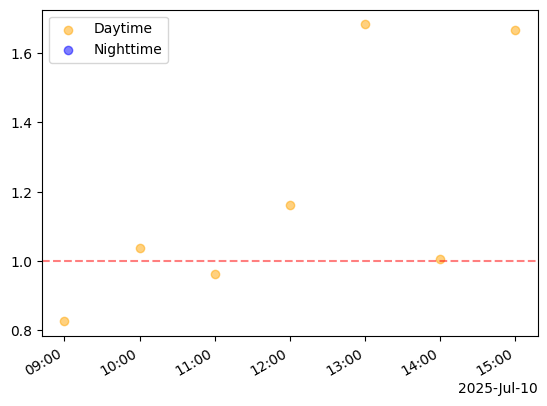

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# Map the J_NO2 values using the hour from the datetime index
data['J_NO2'] = data.index.hour.map(j_data.set_index('Hour')['J_NO2'])

# Calculate LR 
data['LR'] = (data['J_NO2']*data['NO2_mol_per_cm3'])/(data['K']*data['O3_mol_per_cm3']*data['NO_mol_per_cm3'])

fig, ax = plt.subplots()

# daytime = data[data['UV'] > 5]
# nighttime = data[data['UV'] <= 5]
daytime = data.between_time('08:00', '16:00')
nighttime = data.between_time('16:00', '08:00')

ax.scatter(daytime.index, daytime['LR'], c='orange', alpha=0.5, label='Daytime')
ax.scatter(nighttime.index, nighttime['LR'], c='blue', alpha=0.5, label='Nighttime')

ax.legend()
ax.axhline(y=1, color='r', linestyle='--', alpha=0.5)






ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

fig.autofmt_xdate()